In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("train_set_80_percent.csv")
drop_cols = ["id", "rank", "player", "hard_hit_95mph+"]
df = df.drop(columns=drop_cols, errors="ignore")
df = df.dropna()

target = "hard_hit_percentage"
X = df.drop(columns=[target])
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (1261, 15)
Validation shape: (316, 15)


In [3]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVR())
])

param_grid = {
    "svm__kernel": ["rbf", "poly", "linear"],
    "svm__C": [0.1, 1, 10, 50, 100],
    "svm__gamma": ["scale", "auto"],
    "svm__epsilon": [0.1, 0.5, 1.0, 2.0]
}

grid = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest parameters found:")
print(grid.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best parameters found:
{'svm__C': 10, 'svm__epsilon': 0.5, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


In [4]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_val)

r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)

print("\nModel Evaluation on Validation Set:")
print(f"R²  : {r2:.3f}")
print(f"MSE: {mse:.3f}")
print(f"MAE : {mae:.3f}")


Model Evaluation on Validation Set:
R²  : 0.938
MSE: 3.882
MAE : 1.505


In [5]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

result = permutation_importance(
    best_model, X_val, y_val,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print("\nPermutation Importance:")
print(importance_df)


Permutation Importance:
                                feature  importance
13      barrels_batted_balls_percentage    0.352743
14  barrels_plate_appearance_percentage    0.214648
11            hard_hit_swing_percentage    0.212752
5                            average_ev    0.188009
6                fly_ball_line_drive_ev    0.105559
1                    batted_ball_events    0.016679
12                        total_barrels    0.016638
0                                  year    0.013237
3                 sweet_spot_percentage    0.007010
8                          max_distance    0.005209
9                      average_distance    0.003089
4                                max_ev    0.002050
7                        ground_ball_ev    0.000627
2                          launch_angle    0.000034
10                      average_homerun   -0.000038


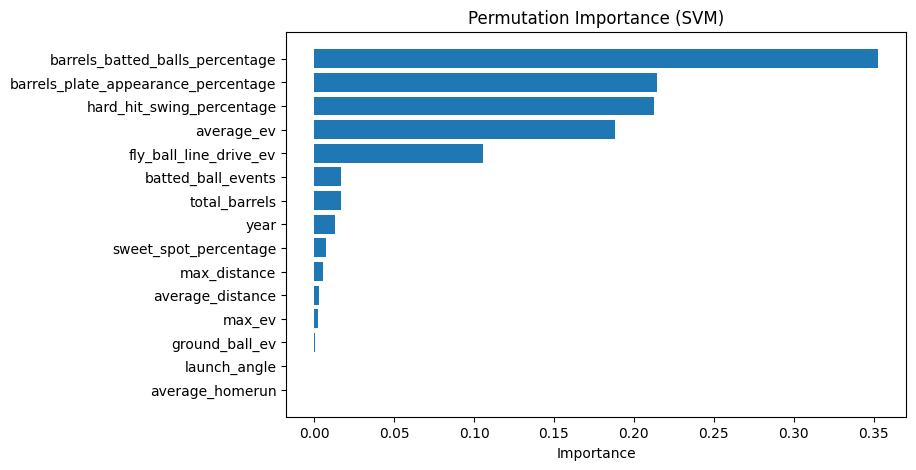

In [6]:
plt.figure(figsize=(8,5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.title("Permutation Importance (SVM)")
plt.show()

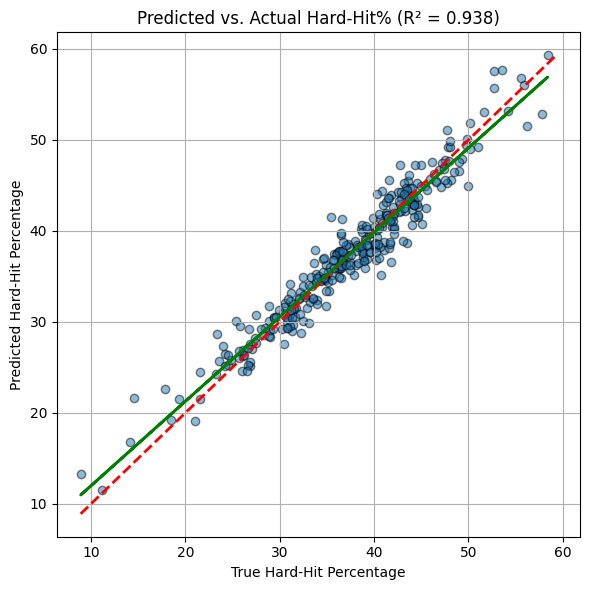

In [7]:
r2 = r2_score(y_val, y_pred)

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.5, edgecolor='k')

min_val = min(min(y_val), min(y_pred))
max_val = max(max(y_val), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

m, b = np.polyfit(y_val, y_pred, 1)
plt.plot(y_val, m*y_val + b, 'g-', linewidth=2)

plt.xlabel("True Hard-Hit Percentage")
plt.ylabel("Predicted Hard-Hit Percentage")
plt.title(f"Predicted vs. Actual Hard-Hit% (R² = {r2:.3f})")

plt.grid(True)
plt.tight_layout()
plt.show()